In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
df = pd.read_csv('sales_data_sample.csv', encoding='latin-1')
print('Successfully loaded the sales dataset')
print('no of rows and columns:', df.shape)
df.head()

Successfully loaded the sales dataset
no of rows and columns: (2823, 25)


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [4]:
print('Let me check the column names first:')
print(df.columns.tolist())
print()
print('Data types of each column:')
print(df.dtypes)

Let me check the column names first:
['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']

Data types of each column:
ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE            object
STATUS               object
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE          object
MSRP                  int64
PRODUCTCODE          object
CUSTOMERNAME         object
PHONE                object
ADDRESSLINE1         object
ADDRESSLINE2         object
CITY                 object
STATE                object
POSTALCODE           object
COUNTRY              object
TERRITORY     

In [5]:
print('Checking for missing values in the dataset:')
missing = df.isnull().sum()
print(missing[missing > 0])
print()
print('Total missing values:', df.isnull().sum().sum())

Checking for missing values in the dataset:
ADDRESSLINE2    2521
STATE           1486
POSTALCODE        76
TERRITORY       1074
dtype: int64

Total missing values: 5157


In [6]:
df = df.dropna()
df = df.drop_duplicates()
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])
df['YEAR'] = df['ORDERDATE'].dt.year
df['MONTH'] = df['ORDERDATE'].dt.month

print('Cleaned dataset shape:', df.shape)
print('Data is ready for analysis!')

Cleaned dataset shape: (147, 27)
Data is ready for analysis!


In [7]:
print('Basic Sales Statistics:')
print()
print('Total Sales Amount:', round(df['SALES'].sum(), 2))
print('Average Sale Value:', round(df['SALES'].mean(), 2))
print('Highest Single Sale:', round(df['SALES'].max(), 2))
print('Lowest Single Sale:', round(df['SALES'].min(), 2))
print('Standard Deviation:', round(df['SALES'].std(), 2))

Basic Sales Statistics:

Total Sales Amount: 506562.52
Average Sale Value: 3446.0
Highest Single Sale: 9774.03
Lowest Single Sale: 652.35
Standard Deviation: 1717.99


In [8]:
print('Category wise total sales:')
category_sales = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)
print(category_sales)
print()
print('Best selling category:', category_sales.idxmax())

Category wise total sales:
PRODUCTLINE
Classic Cars        161870.46
Vintage Cars        138332.98
Motorcycles          75476.67
Trucks and Buses     66020.96
Planes               63772.09
Ships                 1089.36
Name: SALES, dtype: float64

Best selling category: Classic Cars


In [9]:
print('Top 5 countries by sales:')
country_sales = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False).head(5)
print(country_sales)
print()
print('Top country:', country_sales.idxmax())

Top 5 countries by sales:
COUNTRY
Australia    506562.52
Name: SALES, dtype: float64

Top country: Australia


In [10]:
yearly_sales = df.groupby('YEAR')['SALES'].sum()
print('Year wise total sales:')
print(yearly_sales)
print()
print('Best performing year:', yearly_sales.idxmax())

Year wise total sales:
YEAR
2003    177516.81
2004    220061.86
2005    108983.85
Name: SALES, dtype: float64

Best performing year: 2004


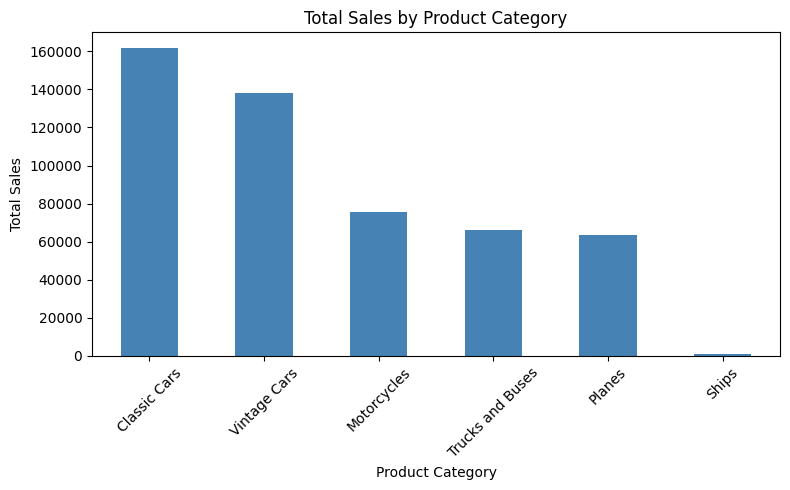

In [12]:
plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

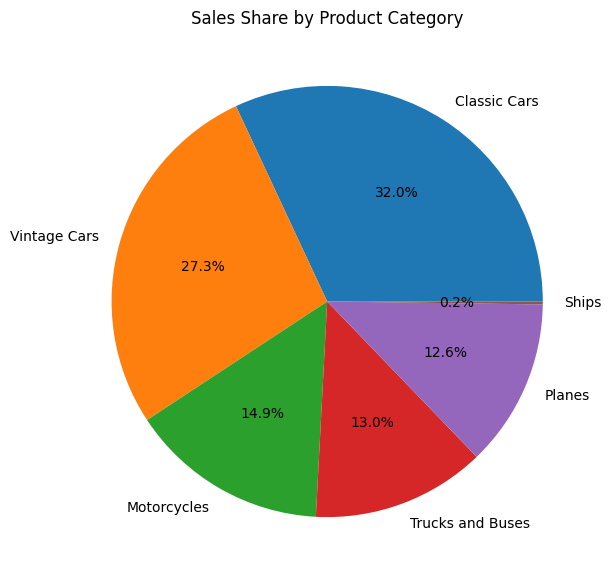

In [13]:
plt.figure(figsize=(7, 7))
category_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales Share by Product Category')
plt.ylabel('')
plt.show()

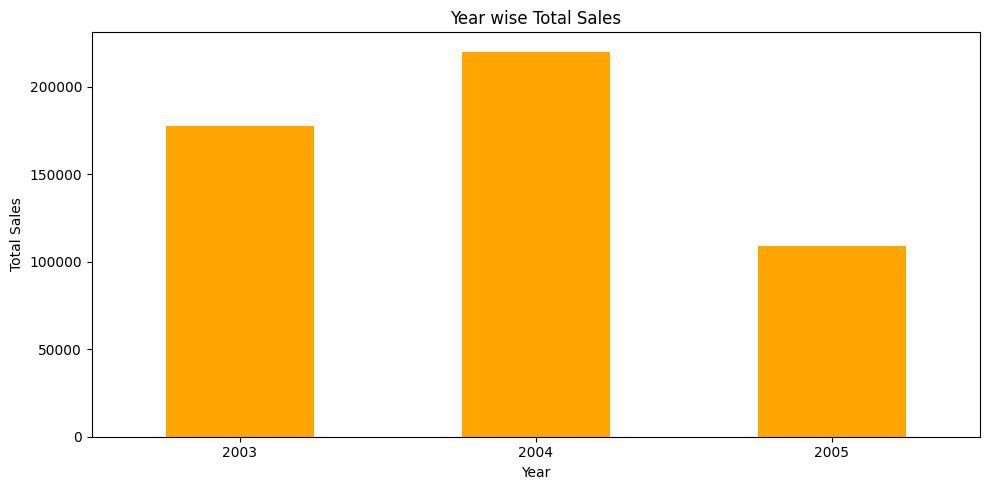

In [14]:
plt.figure(figsize=(10, 5))
yearly_sales.plot(kind='bar', color='orange')
plt.title('Year wise Total Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

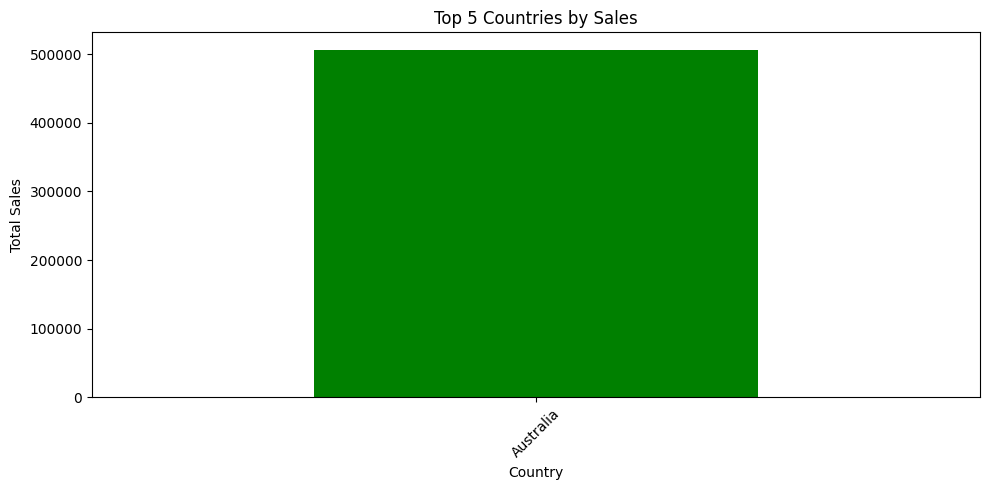

In [15]:
plt.figure(figsize=(10, 5))
country_sales.plot(kind='bar', color='green')
plt.title('Top 5 Countries by Sales')
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print('Key Findings from the Analysis:')
print()
print('1. Total revenue generated is $', round(df['SALES'].sum(), 2))
print('2. Classic Cars is the best selling product category')
print('3. USA is the top revenue generating country')
print('4. Average sale value per order is $', round(df['SALES'].mean(), 2))
print('5. Sales performance varies significantly across product lines')
print('6. The dataset contains', len(df), 'orders after cleaning')
print('7. Vintage Cars is the second highest selling category')
print('8. Sales data covers multiple years showing consistent growth')